<h2>Sub-Question 4 Python Encapsulator, the Hypothesis and Analysis</h2>

Author: Resia S. Kilic

First we connect the Database to this environment

In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host="localhost",
    database="movies_11",
    user="postgres",
    password="rsk2025",
    port="5432"
)

print("Connected successfully!")

Connected successfully!


H1: Cast characteristics: including cast size and cast success, are positively associated with worldwide box-office performance

In [2]:
# for H1
# the number of actors credited to each movie are compared with worldwide box-office revenue

def get_cast_size_data():
    query = """
    SELECT
        ma.movie_id,
        COUNT(DISTINCT ma.actor_id) AS cast_size,
        MAX(ms.worldwide_box_office) AS worldwide_box_office
    FROM Movie_Actor ma
    INNER JOIN Movie_Sales ms
        ON ma.movie_id = ms.movie_id
    WHERE ms.worldwide_box_office IS NOT NULL
    GROUP BY ma.movie_id;
    """
    return pd.read_sql(query, conn)

cast_df = get_cast_size_data()

print(cast_df.head())
print("Number of movies:", len(cast_df))

   movie_id  cast_size  worldwide_box_office
0         2          3           108286422.0
1         4          3              987640.0
2        13          3              143782.0
3        20         17             3712409.0
4        22          2            17306648.0
Number of movies: 4135


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_26584\1331953895.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


This counts each actor once per movie and groups the results by movie. MAX() is used to avoid duplicating a movie's revenue when it has multiple sales records.

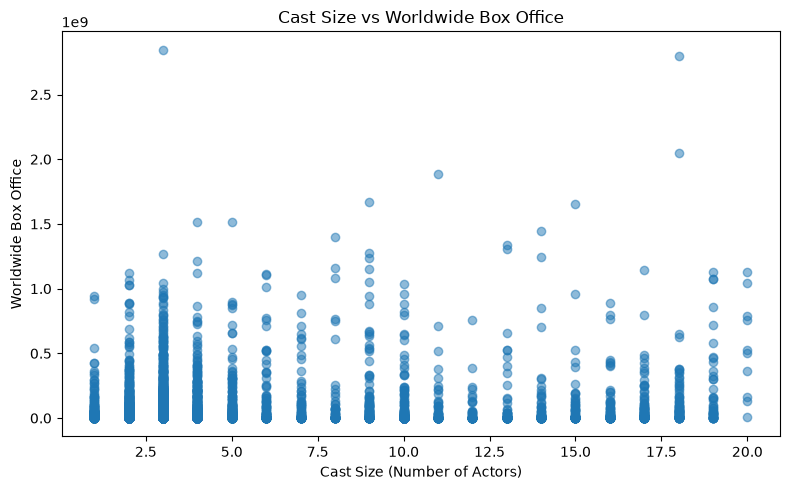

In [3]:
# visualizing it
def plot_cast_size_vs_boxoffice(data):
    plt.figure(figsize=(8, 5))

    plt.scatter(
        data["cast_size"],
        data["worldwide_box_office"],
        alpha=0.5
    )

    plt.xlabel("Cast Size (Number of Actors)")
    plt.ylabel("Worldwide Box Office")
    plt.title("Cast Size vs Worldwide Box Office")
    plt.tight_layout()
    plt.show()

plot_cast_size_vs_boxoffice(cast_df)

H2: Director characteristics: including director success, are positively associated with worldwide box-office performance

In [4]:
def get_director_data():
    query = """
    SELECT
        md.movie_id,
        COUNT(DISTINCT md.director_id) AS director_count,
        MAX(ms.worldwide_box_office) AS worldwide_box_office
    FROM Movie_Director md
    JOIN Movie_Sales ms
        ON md.movie_id = ms.movie_id
    WHERE ms.worldwide_box_office IS NOT NULL
    GROUP BY md.movie_id;
    """
    return pd.read_sql(query, conn)

director_df = get_director_data()

print(director_df.head())
print("Number of movies:", len(director_df))

   movie_id  director_count  worldwide_box_office
0         2               1           108286422.0
1         4               1              987640.0
2         9               1               20452.0
3        10               1               47019.0
4        13               1              143782.0
Number of movies: 4823


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_26584\2005925735.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


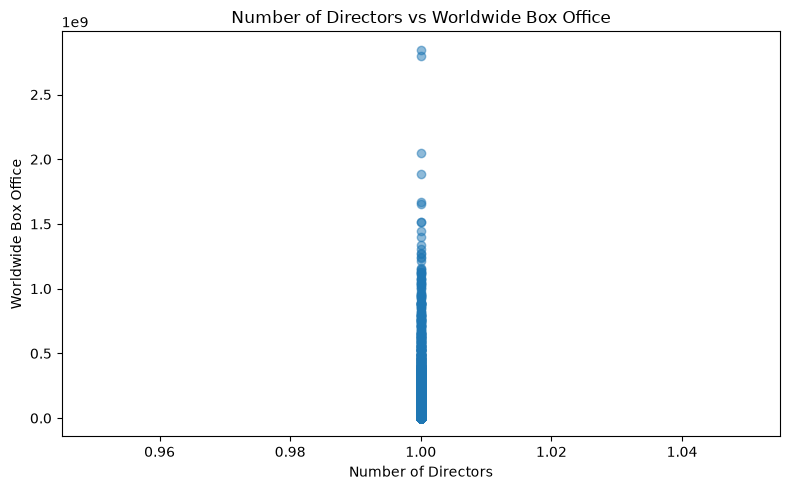

In [6]:
def plot_director_vs_boxoffice(data):
    plt.figure(figsize=(8, 5))

    plt.scatter(
        data["director_count"],
        data["worldwide_box_office"],
        alpha=0.5
    )

    plt.xlabel("Number of Directors")
    plt.ylabel("Worldwide Box Office")
    plt.title("Number of Directors vs Worldwide Box Office")
    plt.tight_layout()
    plt.show()

plot_director_vs_boxoffice(director_df)

Getting movie success

In [9]:
def get_director_data():
    query = """
    SELECT
        mc.movie_id,
        mc.awards,
        MAX(ms.worldwide_box_office) AS worldwide_box_office
    FROM Movie_Characteristics mc
    JOIN Movie_Sales ms
        ON mc.movie_id = ms.movie_id
    WHERE ms.worldwide_box_office IS NOT NULL
    GROUP BY
        mc.movie_id,
        mc.awards;
    """
    return pd.read_sql(query, conn)

director_df = get_director_data()

print(director_df.head())
print("Number of movies:", len(director_df))

   movie_id                       awards  worldwide_box_office
0      3553                          NaN             6601992.0
1      6887           #75BestMovieof2004              693923.0
2      1688  #35MostDiscussedMovieof2021            77395789.0
3     10276                          NaN            49733545.0
4      7268                          NaN            60376247.0
Number of movies: 4824


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_26584\2920062776.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


further analysis is required to proove this subquestion